<a href="https://colab.research.google.com/github/femas66/PCVK_Ganjil_2026/blob/main/M1_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M1_D3 — Pengolahan Citra Dasar & Channel Warna pada OpenCV

In [ ]:
import os
import numpy as np
import cv2 as cv
try:
    from google.colab.patches import cv2_imshow  # hanya ada di Google Colab
except ImportError:
    import matplotlib.pyplot as _plt
    def cv2_imshow(img):
        img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB) if img.ndim == 3 else img
        _plt.imshow(img_rgb)
        _plt.axis('off')
        _plt.show()
import matplotlib.pyplot as plt

### 1. Koneksi Google Drive (jalankan hanya di Google Colab)

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_MOUNTED = True
except ImportError:
    print("Bukan di Google Colab, skip mount drive.")
    DRIVE_MOUNTED = False

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Menyiapkan & Menampilkan Gambar

Ganti `IMG_PATH` dengan path file citra Anda di Google Drive, mis. `/content/drive/MyDrive/PCVK/KTM lama.jpg`. Sebagai default, sel di bawah membuat citra sampel lokal (`sample_image.jpg`) memakai `skimage.data.chelsea()` supaya notebook tetap bisa dijalankan tanpa file pribadi — **ganti ke foto Anda sendiri saat mengumpulkan tugas.**

Resolusi gambar: 1980 x 1272


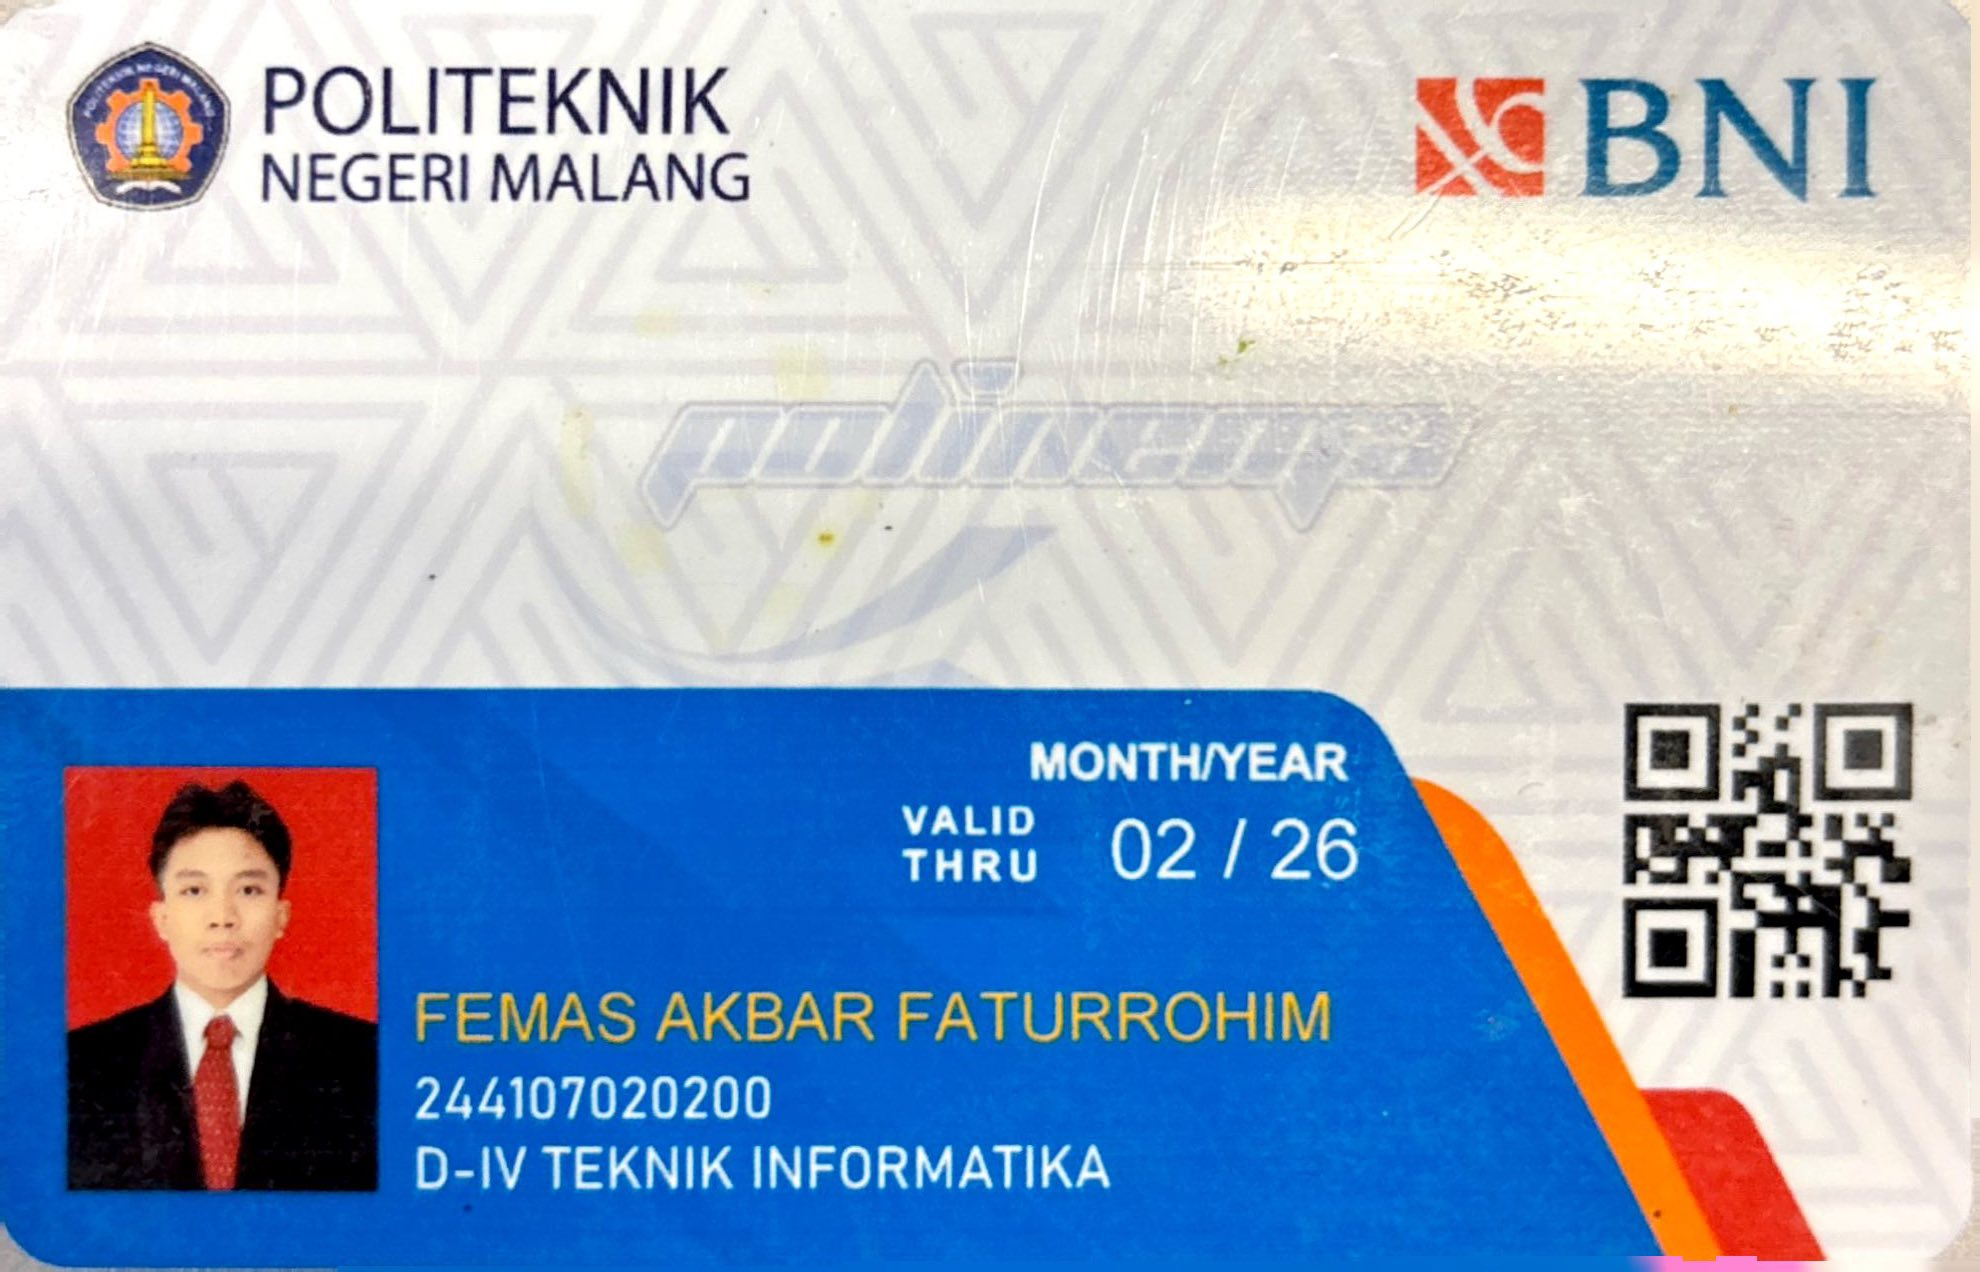

In [ ]:
IMG_PATH = "/content/drive/MyDrive/KTM/KTM Femas Akbar Faturrohim.jpg"  # <-- ganti dengan path citra Anda (mis. path file KTM di Google Drive)

if not os.path.exists(IMG_PATH):
    from skimage import data
    sample = data.chelsea()  # citra sampel bawaan skimage sbg pengganti foto pribadi
    cv.imwrite(IMG_PATH, cv.cvtColor(sample, cv.COLOR_RGB2BGR))

img = cv.imread(IMG_PATH)
print("Resolusi gambar:", img.shape[1], "x", img.shape[0])
cv2_imshow(img)

### Menampilkan Gambar (Image Plotting) dengan Matplotlib

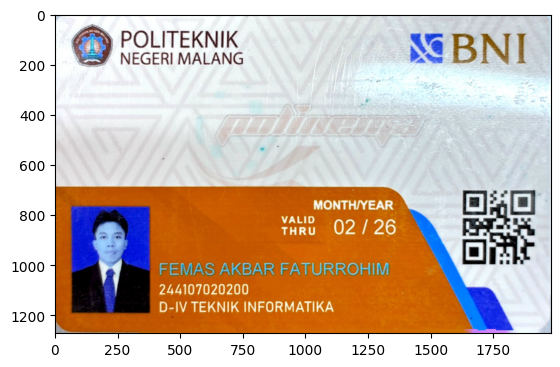

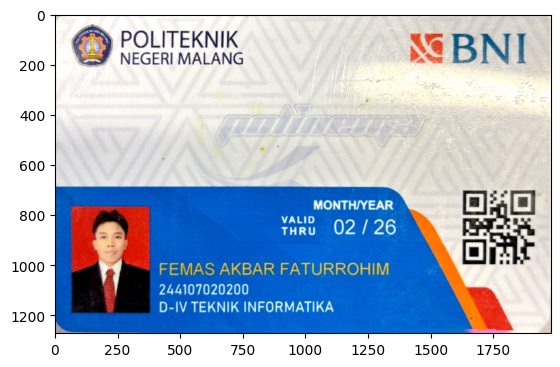

In [ ]:
img = cv.imread(IMG_PATH)
plt.imshow(img)  # format warna BGR (warna tampak keliru)
plt.show()

img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # konversi BGR ke RGB
plt.imshow(img2)
plt.show()

### 3. Menampilkan Citra Grayscale

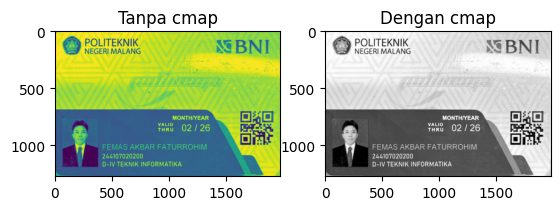

In [ ]:
img_gray = cv.imread(IMG_PATH, cv.IMREAD_GRAYSCALE)

plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title("Tanpa cmap")

plt.subplot(1,2,2)
plt.imshow(img_gray, cmap="gray")
plt.title("Dengan cmap")
plt.show()

### 4. Resizing

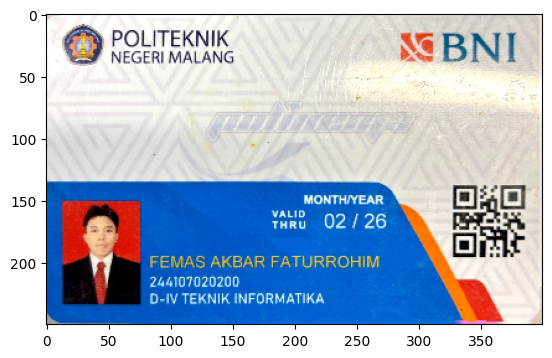

In [ ]:
img = cv.imread(IMG_PATH)
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)
imgRGBsmall = cv.resize(imgRGB, (400,250))
plt.imshow(imgRGBsmall)
plt.show()

### 5. Flipping

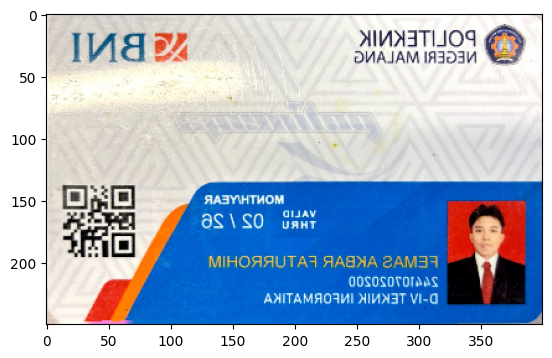

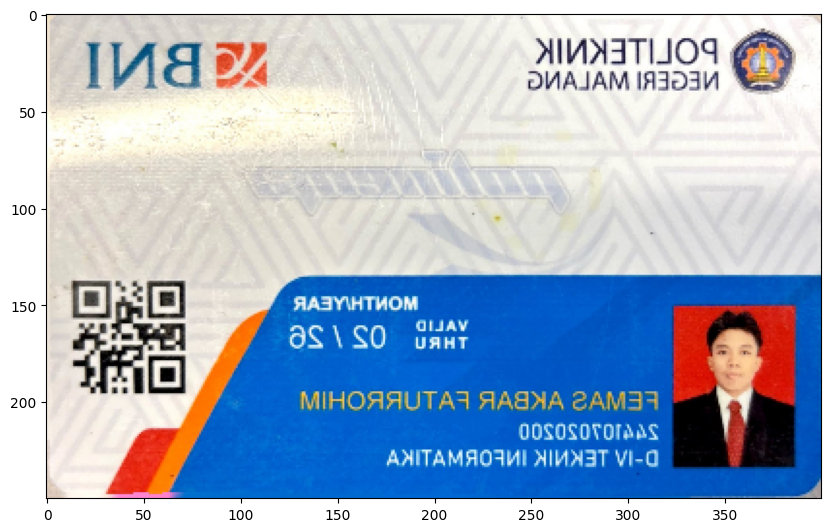

In [ ]:
imgBalik = cv.flip(imgRGBsmall, 1)
plt.imshow(imgBalik)
plt.show()

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.imshow(imgBalik)
plt.show()

### 6. Geometri 2D dengan OpenCV

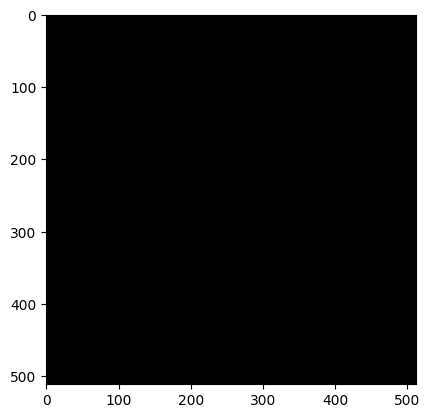

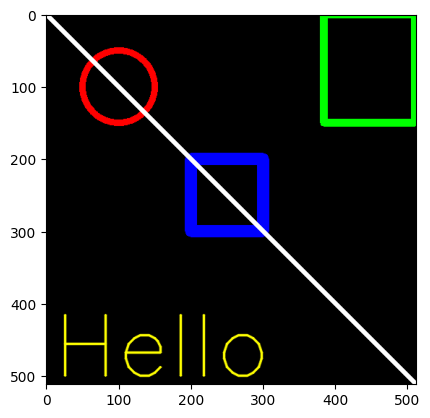

In [ ]:
black_img = np.zeros(shape=(512,512,3), dtype=np.int16)
plt.imshow(black_img)
plt.show()

# persegi panjang
cv.rectangle(black_img, pt1=(384,0), pt2=(510,150), color=(0,255,0), thickness=10)
cv.rectangle(black_img, pt1=(200,200), pt2=(300,300), color=(0,0,255), thickness=15)

# lingkaran
cv.circle(black_img, center=(100,100), radius=50, color=(255,0,0), thickness=8)

# garis
cv.line(black_img, pt1=(0,0), pt2=(512,512), color=(255,255,255), thickness=5)

# text (opencv baru butuh tipe data CV_8U/uint8 utk putText)
black_img = black_img.astype(np.uint8)
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='Hello', org=(10,500), fontFace=font, fontScale=4, color=(255,255,0), thickness=2, lineType=cv.LINE_AA)

plt.imshow(black_img)
plt.show()

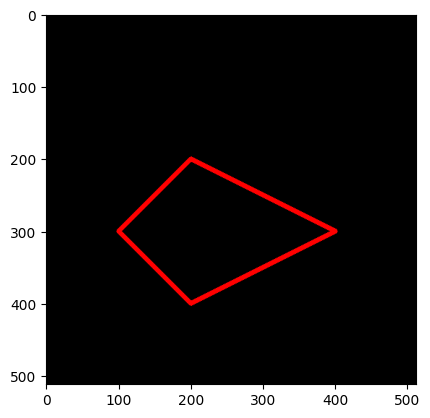

In [ ]:
# black image dengan tipe data int32 + polyline
black_img2 = np.zeros(shape=(512,512,3), dtype=np.int32)

vertices = np.array([[100,300],[200,200],[400,300],[200,400]], dtype=np.int32)
pts = vertices.reshape((-1,1,2))  # nilai 2 menunjukkan tiap titik dibuat 1 baris x 2 kolom (x,y)

black_img2 = black_img2.astype(np.uint8)
cv.polylines(black_img2, [pts], isClosed=True, color=(255,0,0), thickness=5)
plt.imshow(black_img2)
plt.show()

## PERTANYAAN PRAKTIKUM D3

**1. Perbedaan gambar yang ditampilkan tanpa dan dengan matplotlib?**

Tanpa matplotlib (mis. `cv2_imshow`/`cv2.imshow`), citra ditampilkan langsung sebagai gambar utuh tanpa informasi sumbu/skala — hanya visual gambar. Dengan matplotlib (`plt.imshow`), citra ditampilkan sebagai *plot* lengkap dengan sumbu x-y (dalam satuan pixel), sehingga ukuran lebar-tinggi citra dan koordinat piksel tertentu bisa langsung dibaca dari grafik, serta bisa ditambah title, colormap, subplot, dsb. Perbedaan lain: matplotlib menampilkan array sesuai urutan channel data (misal BGR dari OpenCV akan tampak warnanya salah/terbalik jika tidak dikonversi ke RGB dulu), sedangkan `cv2_imshow` di Colab otomatis menampilkan sesuai BGR (default OpenCV) dengan benar.

**2. Perbedaan dan pengaruh pembuatan black image antara tipe data int16 dan int32?**

Keduanya sama-sama tipe integer bertanda (*signed*), bedanya kapasitas/rentang nilai: `int16` menyimpan nilai -32.768 s.d 32.767 (2 byte per elemen), sedangkan `int32` menyimpan rentang jauh lebih besar, -2.147.483.648 s.d 2.147.483.647 (4 byte per elemen). Untuk nilai piksel citra (0-255) keduanya sama-sama cukup dan secara visual hasil citra hitamnya identik. Pengaruhnya lebih ke penggunaan memori (int32 dua kali lebih besar dari int16) dan kecocokan dengan fungsi tertentu — beberapa fungsi OpenCV modern (mis. `cv2.putText`) mensyaratkan tipe data `uint8` (CV_8U), sehingga array int16/int32 perlu dikonversi (`.astype(np.uint8)`) dulu sebelum dipakai fungsi tersebut, kalau tidak akan muncul error assertion.

**3. Kegunaan `from google.colab.patches import cv2_imshow`?**

Fungsi `cv2.imshow()` bawaan OpenCV membuka jendela GUI terpisah untuk menampilkan gambar, yang tidak didukung di lingkungan Google Colab (berjalan di server, tanpa display). `cv2_imshow` dari `google.colab.patches` adalah pengganti khusus Colab yang menampilkan citra langsung sebagai output sel notebook (mirip menampilkan gambar di web), sehingga citra hasil olahan OpenCV tetap bisa dilihat di Colab.

**4. Kegunaan `from skimage import io`?**

Modul `io` pada scikit-image (`skimage.io`) menyediakan fungsi untuk *input/output* citra, terutama `io.imread()` yang dapat membaca citra baik dari file lokal maupun langsung dari URL (link internet), lalu mengembalikannya sebagai array numpy siap diolah — inilah yang dipakai pada Langkah 2 (di M1_D2) untuk membaca citra dari daftar URL.

## TUGAS PRAKTIKUM D3

Berdasarkan praktikum bagian 1 dan 2.

**1. Menggunakan figsize, apakah ukuran image pixelnya juga berubah?**

`figsize` hanya mengubah ukuran *canvas/figure* matplotlib saat ditampilkan (ukuran render di layar/di layout notebook) — bukan ukuran data citra itu sendiri. Array `imgRGB.shape` (jumlah pixel sebenarnya) tetap sama sebelum dan sesudah `figsize` diubah, dibuktikan pada sel di bawah.

In [ ]:
print("Shape sebelum figsize:", imgRGB.shape)

fig = plt.figure(figsize=(2,2))
plt.imshow(imgRGB)
plt.title("figsize kecil (2,2)")
plt.show()

fig = plt.figure(figsize=(12,12))
plt.imshow(imgRGB)
plt.title("figsize besar (12,12)")
plt.show()

print("Shape sesudah figsize:", imgRGB.shape, "-> TIDAK berubah, hanya tampilan render yang membesar/mengecil")

**2. Tampilkan image dalam channel Red-Blue dan Green-Blue saja!**

In [ ]:
R, G, B = cv.split(imgRGB)
zero = np.zeros_like(R)

img_RB = cv.merge([R, zero, B])   # hanya channel Red & Blue
img_GB = cv.merge([zero, G, B])   # hanya channel Green & Blue

plt.subplot(1,2,1); plt.imshow(img_RB); plt.title("Red-Blue")
plt.subplot(1,2,2); plt.imshow(img_GB); plt.title("Green-Blue")
plt.show()

**3. Tampilkan image baris ke 20-115, kolom 25-120!**

In [ ]:
crop1 = imgRGB[20:115, 25:120]
plt.imshow(crop1)
plt.show()

**4. Tampilkan image baris ke 5-30, semua kolom, channel Red saja!**

In [ ]:
crop2 = imgRGB[5:30, :, 0]  # index 0 = channel Red
plt.imshow(crop2, cmap="gray")
plt.show()

**5. Buat 5 kotak berbagai ukuran dan warna berbeda dalam satu image (pakai bilangan acak/random)!**

In [ ]:
canvas = imgRGB.copy()
rng = np.random.default_rng(42)
h, w = canvas.shape[:2]

for i in range(5):
    x1, y1 = int(rng.integers(0, w-50)), int(rng.integers(0, h-50))
    bw, bh = int(rng.integers(20,80)), int(rng.integers(20,80))
    x2, y2 = min(x1+bw, w-1), min(y1+bh, h-1)
    color = tuple(int(c) for c in rng.integers(0,255,3))
    cv.rectangle(canvas, (x1,y1), (x2,y2), color, thickness=3)

plt.imshow(canvas)
plt.show()

**6. Tampilkan image dengan posisi terbalik!**

In [ ]:
flipped = cv.flip(imgRGB, -1)  # -1 = balik horizontal & vertikal sekaligus
plt.imshow(flipped)
plt.show()

Berdasarkan praktikum bagian 3 dan 4.

**7. Buat rectangle dan circle pada bagian wajah dari foto Anda saat beraktifitas (bukan pasfoto)**

Ganti `IMG_PATH_AKTIVITAS` di bawah dengan path foto beraktifitas Anda sendiri (upload ke Colab/Drive terlebih dulu), lalu jalankan sel ini.

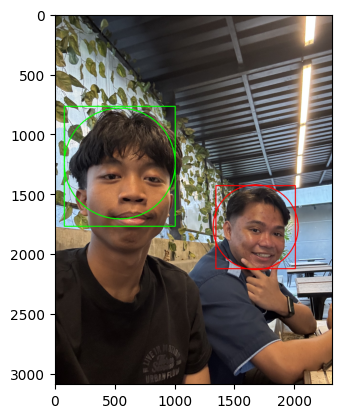

In [12]:
IMG_PATH_AKTIVITAS = "/content/drive/MyDrive/PCVK/IMG_4799.JPG"

img_aktivitas = cv.imread(IMG_PATH_AKTIVITAS)
if img_aktivitas is None:
    print("File belum ada. Upload foto Anda lalu set IMG_PATH_AKTIVITAS ke path-nya.")
else:
    img_aktivitas_rgb = cv.cvtColor(img_aktivitas, cv.COLOR_BGR2RGB)
    cv.rectangle(img_aktivitas_rgb, pt1=(77,770), pt2=(1001,1771), color=(0,255,0), thickness=8)
    cv.circle(img_aktivitas_rgb, center=(539,1247), radius=462, color=(0,255,0), thickness=8)
    cv.rectangle(img_aktivitas_rgb, pt1=(1340,1432), pt2=(2002,2125), color=(255,0,0), thickness=8)
    cv.circle(img_aktivitas_rgb, center=(1671,1779), radius=354, color=(255,0,0), thickness=8)
    plt.imshow(img_aktivitas_rgb)
    plt.show()

**8-9. Rectangle pada sudut bawah kiri channel B (RGB) dari citra kitten/lena/mandrill/dst + tulisan nama file**

Menggunakan citra sampel kucing (`data.chelsea`, setara "kitten" pada daftar modul) sebagai contoh. Jika dosen menyediakan file kitten/lena/mandrill dsb secara spesifik, ganti `IMG_PATH` menjadi path file tersebut.

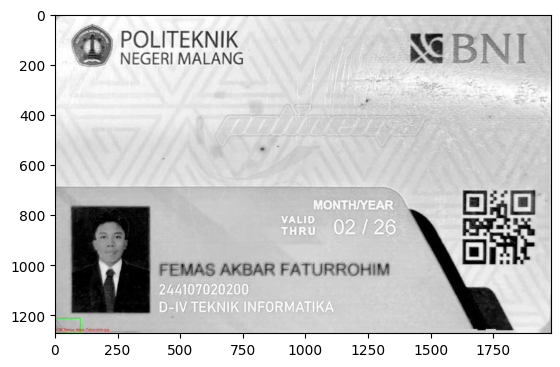

In [13]:
img_src = cv.imread(IMG_PATH)
img_rgb = cv.cvtColor(img_src, cv.COLOR_BGR2RGB)

# channel B pada color space RGB adalah index ke-2
channel_B = img_rgb[:, :, 2].copy()
channel_B_bgr = cv.cvtColor(channel_B, cv.COLOR_GRAY2BGR)  # supaya rectangle/text warna bisa tampil

h, w = channel_B.shape
box_w, box_h = 100, 60
# sudut bawah kiri
pt1 = (0, h - box_h)
pt2 = (box_w, h)
cv.rectangle(channel_B_bgr, pt1, pt2, color=(0,255,0), thickness=2)

font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(channel_B_bgr, text=os.path.basename(IMG_PATH), org=(5, h-10),
           fontFace=font, fontScale=0.4, color=(0,0,255), thickness=1, lineType=cv.LINE_AA)

plt.imshow(cv.cvtColor(channel_B_bgr, cv.COLOR_BGR2RGB))
plt.show()

**10. Tunjukkan code program Anda pada bapak/ibu dosen** — jalankan seluruh notebook ini dan tunjukkan hasilnya saat sesi praktikum.